# **Exploratory Data Analysis (EDA)**

## Objectives

The purpose of this notebook is to leverage Exploratory Data Analysis (EDA) to investigate and gain a comprehensive understanding of the dataset, including its patterns and trends. Specifically, the EDA process will:

* Perform descriptive analysis to summarize the data
* Create and refine features through feature engineering
* Test hypotheses using statistical methods
* Generate visualizations to highlight trends and relationships
*  Extract insights from the data to address key business questions

## Inputs

* cleaned_worldcup_data.csv from the ETL notebook

## Outputs

* Tested hypothesis
* Data visualisations created using Matplotlib, Seaborn and Plotly
* A new processed dataset

## Additional Comments

* Python 3.12.8 needed
* Required Python Libaries from requirements.txt and their dependencies are needed
* Completed ETL step



---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'c:\\Users\\admin\\Documents\\vscode-projects\\football-worldcup-analysis\\jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'c:\\Users\\admin\\Documents\\vscode-projects\\football-worldcup-analysis'

## Initial Setup

### Import Libraries

Import libraries that are needed 

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

### Load data from CSV 

Load data exported from the ETL jupyter notebook

In [14]:
df = pd.read_csv('data/cleaned/cleaned_worldcup_data.csv')
df.head()

,Position,Team,Games Played,Win,Draw,Loss,Goals For,Goals Against,Goal Difference,Points,Year
0,1,Uruguay,4,4,0,0,15,3,12,8,1930
1,2,Argentina,5,4,0,1,18,9,9,8,1930
2,3,United States,3,2,0,1,7,6,1,4,1930
3,4,Yugoslavia,3,2,0,1,7,7,0,4,1930
4,5,Chile,3,2,0,1,5,3,2,4,1930


---

## Initial hypothesis

* The average number of goals per team per World Cup has increased over time.
* The distribution of points per team has become more balanced over time.
* Teams that performed well in one World Cup (top 4) tend to perform well in the next.
* Teams with higher goal differences achieve more points.
* A strong defense (fewer Goals Against) contributes more to success than a strong offense (Goals For).

* Teams that draw fewer matches tend to earn more total points.

---

### Descriptive Analysis

This step is is all about summarizing and understanding your data before diving into deeper exploration or modeling

In [15]:
print(df.shape) # Print the shape of the DataFrame
print(df.dtypes) # Print the data types of each column
print(df.head()) # Display the first few rows of the DataFrame

(489, 11)
Position            int64
Team               object
Games Played        int64
Win                 int64
Draw                int64
Loss                int64
Goals For           int64
Goals Against       int64
Goal Difference     int64
Points              int64
Year                int64
dtype: object
   Position           Team  Games Played  Win  Draw  Loss  Goals For  \
0         1        Uruguay             4    4     0     0         15   
1         2      Argentina             5    4     0     1         18   
2         3  United States             3    2     0     1          7   
3         4     Yugoslavia             3    2     0     1          7   
4         5          Chile             3    2     0     1          5   

   Goals Against  Goal Difference  Points  Year  
0              3               12       8  1930  
1              9                9       8  1930  
2              6                1       4  1930  
3              7                0       4  1930  
4      

In [16]:
# Numerical summary
print(df.describe())

# Categorical summary
print(df['Team'].value_counts())

         Position  Games Played         Win        Draw        Loss  \
count  489.000000    489.000000  489.000000  489.000000  489.000000   
mean    12.838446      3.938650    1.541922    0.854806    1.541922   
std      8.306900      1.469749    1.550641    0.864476    0.778016   
min      1.000000      1.000000    0.000000    0.000000    0.000000   
25%      6.000000      3.000000    0.000000    0.000000    1.000000   
50%     12.000000      3.000000    1.000000    1.000000    2.000000   
75%     18.000000      5.000000    2.000000    1.000000    2.000000   
max     32.000000      7.000000    7.000000    4.000000    3.000000   

        Goals For  Goals Against  Goal Difference      Points         Year  
count  489.000000     489.000000       489.000000  489.000000   489.000000  
mean     5.560327       5.560327         0.000000    4.730061  1987.186094  
std      4.527346       2.748498         4.733037    4.151429    26.098178  
min      0.000000       0.000000       -16.000000   

#### Key observations from Descriptive Statistics

* Position - most teams participating are mid-ranked as the mean position is around 12.8
* Games played - Range is 1 to 7 and most teams play around 4 games as the mean is around 3.94
* Win, Draw, Loss - Maximum Loss is 3 which means that with 3 losses the team is always out of the competition
* Goals For/Against - Min Goals For is 0 and Max Goals For is 27 which means there is wide variation in team performance
* Points - Mean Points is 4.73 and Median is 4 which means points are spread around the mid-range
* Year - Range is between 1930 and 2022 as this dataset includes historical data over 90 years 


#### Insights

* Most teams are mid-table, with few consistently winning or losing.
* Goal scoring is fairly balanced on average, but extreme performances exist.
* The dataset includes a wide historical range, which could reveal trends over decades.
* Variability (std) is quite high for Goals For, Goal Difference, and Points, indicating uneven team performance.

---

### Feature Engineering

In this section new features will be added in order to have a precise hypothesis testing and better visualisations.

In [17]:
 # Sort by Team and Year
df = df.sort_values(by=['Team', 'Year'])
# Create Prev_Position by shifting Position within each Team group
df['Prev_Position'] = df.groupby('Team')['Position'].shift(1)
# Fill NaN values in Prev_Position with 0 (for first occurrence of each team) and convert to integer
df['Prev_Position'] = df['Prev_Position'].fillna(0).astype(int)
# Display the updated DataFrame
df.head()

,Position,Team,Games Played,Win,Draw,Loss,Goals For,Goals Against,Goal Difference,Points,Year,Prev_Position
181,13,Algeria,3,2,0,1,5,5,0,4,1982,0
214,22,Algeria,3,0,1,2,1,5,-4,1,1986,13
388,28,Algeria,3,0,1,2,0,2,-2,1,2010,22
406,14,Algeria,4,1,1,2,7,7,0,4,2014,28
351,23,Angola,3,0,2,1,1,2,-1,2,2006,0


---

### Hypothesis Testing

The following hypotheses are subject to testing through statistical methods:
* Hypothesis 1: The average number of goals per team per World Cup has increased over time.
* Hypothesis 2: The distribution of points per team has become more balanced over time.
* Hypothesis 3: Teams that performed well in one World Cup (top 4) tend to perform well in the next.
* Hypothesis 4: Teams with higher goal differences achieve more points.
* Hypothesis 5: A strong defense (fewer Goals Against) contributes more to success than a strong offense (Goals For).

* Hypothesis 6: Teams that draw fewer matches tend to earn more total points.

#### Hypothesis 1: 

The average number of goals per team per World Cup has increased over time.

In [19]:
# Group by Year and calculate average goals
avg_goals_by_year = df.groupby('Year')['Goals For'].mean()
# Display the results
print(avg_goals_by_year)


Year
1930    5.384615
1934    4.312500
1938    5.600000
1950    6.769231
1954    8.750000
1958    7.875000
1962    5.562500
1966    5.562500
1970    5.937500
1974    6.062500
1978    6.375000
1982    6.083333
1986    5.500000
1990    4.791667
1994    5.875000
1998    5.343750
2002    5.031250
2006    4.593750
2010    4.531250
2014    5.343750
2018    5.281250
2022    5.375000
Name: Goals For, dtype: float64


In [21]:
from scipy import stats

# Correlation test
r, p = stats.pearsonr(avg_goals_by_year.index, avg_goals_by_year.values)

print(f"Correlation: {r:.4f}")
print(f"P-value: {p:.4f}")
print(f"Significant: {'YES' if p < 0.05 else 'NO'}")

Correlation: -0.3484
P-value: 0.1121
Significant: NO


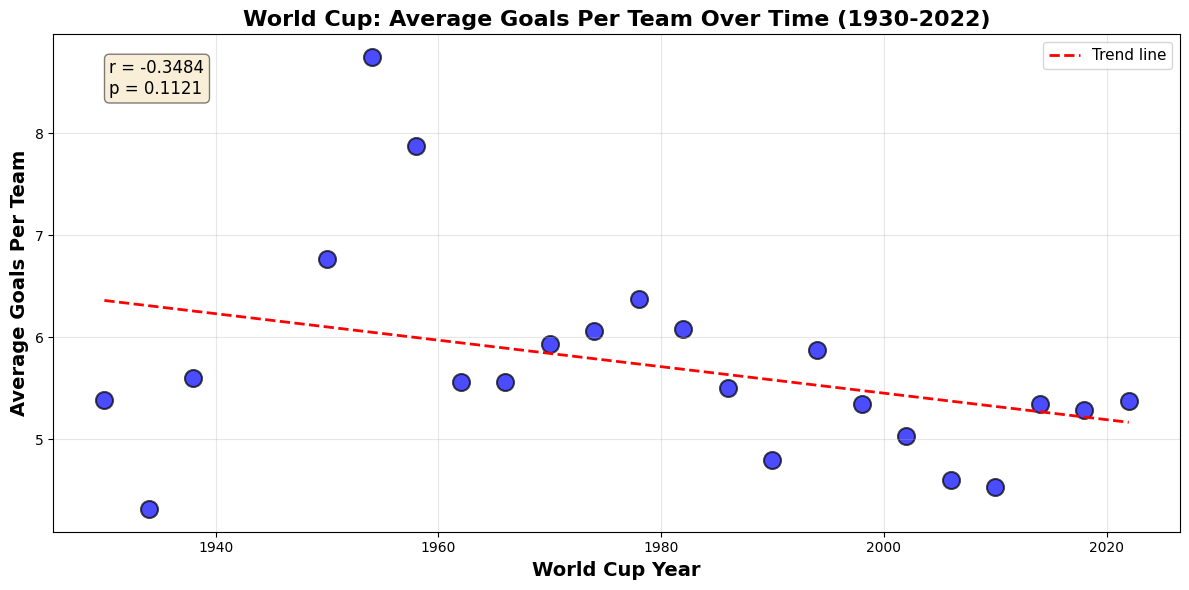

In [22]:
# Plot
plt.figure(figsize=(12, 6))
plt.scatter(avg_goals_by_year.index, avg_goals_by_year.values, 
            s=150, alpha=0.7, color='blue', edgecolors='black', linewidth=1.5)

# Add trend line
z = np.polyfit(avg_goals_by_year.index, avg_goals_by_year.values, 1)
p_line = np.poly1d(z)
plt.plot(avg_goals_by_year.index, p_line(avg_goals_by_year.index), 
         "r--", linewidth=2, label=f'Trend line')

# Add correlation info
plt.text(0.05, 0.95, f'r = {r:.4f}\np = {p:.4f}', 
         transform=plt.gca().transAxes, fontsize=12,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.xlabel('World Cup Year', fontsize=14, fontweight='bold')
plt.ylabel('Average Goals Per Team', fontsize=14, fontweight='bold')
plt.title('World Cup: Average Goals Per Team Over Time (1930-2022)', 
          fontsize=16, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

# Push files to Repo

* In cases where you don't need to push files to Repo, you may replace this section with "Conclusions and Next Steps" and state your conclusions and next steps.

In [ ]:
import os
try:
  # create your folder here
  # os.makedirs(name='')
except Exception as e:
  print(e)
